# Part 3: Customer Churn Prediction Model

Author: Prateek Parmar

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import pickle
import json

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Load Datasets

customers = pd.read_csv("../d2c churn data package/customers.csv")
orders = pd.read_csv("../d2c churn data package/orders.csv")
churn_labels = pd.read_csv("../d2c churn data package/churn_labels.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [4]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [5]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [6]:
churn_labels.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


# Date Preprocessing

In [16]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

churn_labels['snapshot_date'] = pd.to_datetime(
    churn_labels['snapshot_date']
)

print("Date conversion completed successfully")

Date conversion completed successfully


# Feature Engineering

In [17]:
customer_features = orders.groupby(
    'customer_id'
).agg({

    'order_id': 'count',

    'gross_amount': [
        'sum',
        'mean'
    ],

    'delivery_days': 'mean',

    'returned': 'mean',

    'rating': 'mean'

})

In [18]:
customer_features.columns = [

    'total_orders',
    'total_spent',
    'avg_order_value',
    'avg_delivery_days',
    'return_rate',
    'avg_rating'

]

customer_features = customer_features.reset_index()

customer_features.head()

,customer_id,total_orders,total_spent,avg_order_value,avg_delivery_days,return_rate,avg_rating
0,CUST00001,6,2955.57,492.595000,3.500000,0.166667,3.333333
1,CUST00002,3,1713.10,571.033333,3.333333,0.000000,4.333333
2,CUST00003,1,649.98,649.980000,2.000000,0.000000,2.000000
3,CUST00004,1,1604.04,1604.040000,5.000000,0.000000,2.000000
4,CUST00005,6,3910.43,651.738333,5.166667,0.000000,2.333333


# Merge Features with Churn Labels

In [19]:
model_data = customer_features.merge(

    churn_labels,

    on='customer_id',

    how='left'

)

model_data.head()

,customer_id,total_orders,total_spent,avg_order_value,avg_delivery_days,return_rate,avg_rating,snapshot_date,churn_next_60d,split
0,CUST00001,6,2955.57,492.595000,3.500000,0.166667,3.333333,2025-09-30,1,train
1,CUST00002,3,1713.10,571.033333,3.333333,0.000000,4.333333,2025-09-30,0,train
2,CUST00003,1,649.98,649.980000,2.000000,0.000000,2.000000,2025-09-30,1,train
3,CUST00004,1,1604.04,1604.040000,5.000000,0.000000,2.000000,2025-09-30,1,train
4,CUST00005,6,3910.43,651.738333,5.166667,0.000000,2.333333,2025-09-30,0,train


In [27]:
# Dataset Shape

model_data.shape

(2400, 10)

In [24]:
# Missing Value Analysis

model_data.isnull().sum()

customer_id          0
total_orders         0
total_spent          0
avg_order_value      0
avg_delivery_days    0
return_rate          0
avg_rating           4
snapshot_date        0
churn_next_60d       0
split                0
dtype: int64

# Feature Selection

In [28]:
X = model_data[

    [

        'total_orders',
        'total_spent',
        'avg_order_value',
        'avg_delivery_days',
        'return_rate',
        'avg_rating'

    ]

]

y = model_data['churn_next_60d']

In [29]:
X = model_data[

    [

        'total_orders',
        'total_spent',
        'avg_order_value',
        'avg_delivery_days',
        'return_rate',
        'avg_rating'

    ]

]

y = model_data['churn_next_60d']

In [30]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (1920, 6)
Testing Shape: (480, 6)


In [31]:
# Model Training

model = RandomForestClassifier(

    random_state=42

)

model.fit(

    X_train,
    y_train

)

print("Model trained successfully")

Model trained successfully


# Model Evaluation

In [32]:
y_pred = model.predict(X_test)

In [33]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.6520833333333333
Precision: 0.65
Recall   : 0.5294117647058824
F1 Score : 0.5835411471321695


In [34]:
print(

    classification_report(

        y_test,
        y_pred

    )

)

              precision    recall  f1-score   support

           0       0.65      0.76      0.70       259
           1       0.65      0.53      0.58       221

    accuracy                           0.65       480
   macro avg       0.65      0.64      0.64       480
weighted avg       0.65      0.65      0.65       480



# Confusion Matrix

In [35]:
cm = confusion_matrix(

    y_test,
    y_pred

)

cm

array([[196,  63],
       [104, 117]])

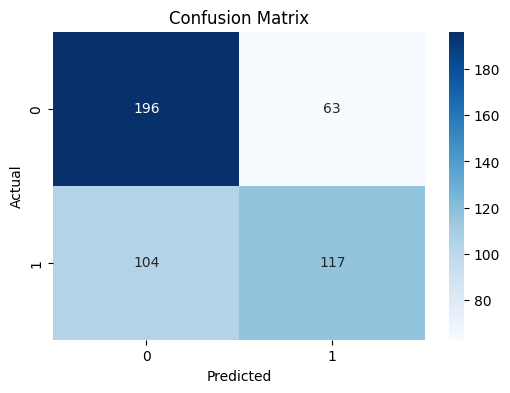

In [36]:
plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance Analysis

In [37]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

feature_importance

,Feature,Importance
1,total_spent,0.287495
2,avg_order_value,0.222380
0,total_orders,0.174565
3,avg_delivery_days,0.141240
5,avg_rating,0.136823
4,return_rate,0.037498


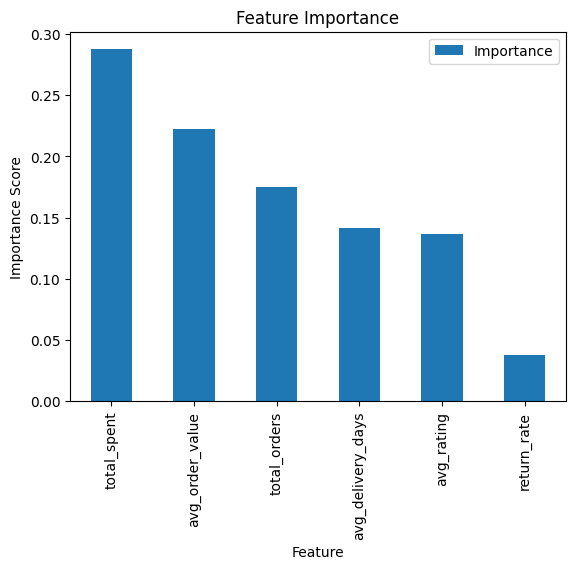

In [38]:
feature_importance.plot(

    x='Feature',

    y='Importance',

    kind='bar'

)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

In [39]:
# Save Trained Model

with open('model.pkl', 'wb') as file:

    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [40]:
# Save Metrics

metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1)

}

with open('metrics.json', 'w') as file:

    json.dump(

        metrics,

        file,

        indent=4

    )

print("Metrics saved successfully")

Metrics saved successfully
